In [1]:
from __future__ import annotations

from pathlib import Path
import importlib
import os
import subprocess
import sys

import pandas as pd

PROJECT_ROOT = Path("/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project")
RESULTS_DIR = PROJECT_ROOT / "results" / "bayesian_es_baselines_20042026"
os.environ["MPLCONFIGDIR"] = str(RESULTS_DIR / ".mplconfig")
os.environ["XDG_CACHE_HOME"] = str(RESULTS_DIR / ".cache")
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
(RESULTS_DIR / ".mplconfig").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / ".cache").mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils import bayesian_energy_signature as bes


def _safe_import_check(config: bes.Config) -> pd.DataFrame:
    rows: list[dict[str, object]] = []

    def add(check: str, ok: bool, version: str | None = None, detail: str = "") -> None:
        rows.append({"check": check, "ok": bool(ok), "version": version, "detail": detail})

    env = os.environ.copy()
    for key in (
        "MPLCONFIGDIR",
        "XDG_CACHE_HOME",
        "OMP_NUM_THREADS",
        "OPENBLAS_NUM_THREADS",
        "MKL_NUM_THREADS",
        "VECLIB_MAXIMUM_THREADS",
        "NUMEXPR_NUM_THREADS",
    ):
        env[key] = os.environ.get(key, env.get(key, ""))

    for name in ("pytensor", "arviz", "pymc"):
        probe = (
            "import importlib, json; "
            f"m=importlib.import_module('{name}'); "
            "print(json.dumps({'version': getattr(m, '__version__', 'unknown')}))"
        )
        proc = subprocess.run(
            [sys.executable, "-c", probe],
            env=env,
            capture_output=True,
            text=True,
        )
        if proc.returncode == 0:
            version = "unknown"
            out = (proc.stdout or "").strip()
            if out:
                try:
                    import json

                    version = str(json.loads(out).get("version", "unknown"))
                except Exception:
                    version = out
            add(name, True, version, "subprocess import ok")
        else:
            detail = ((proc.stderr or "") + (proc.stdout or "")).strip()
            add(name, False, None, detail[:500])

    mpl_dir = config.results_dir / ".mplconfig"
    try:
        mpl_dir.mkdir(parents=True, exist_ok=True)
        test_file = mpl_dir / ".write_test"
        test_file.write_text("ok", encoding="utf-8")
        test_file.unlink(missing_ok=True)
        add("MPLCONFIGDIR_writable", True, None, str(mpl_dir))
    except Exception as exc:
        add("MPLCONFIGDIR_writable", False, None, f"{type(exc).__name__}: {exc}")

    return pd.DataFrame(rows)


# Monkey-patch BES env checks to avoid hard crashes in-process from native imports.
def _patched_check_environment(config: bes.Config) -> pd.DataFrame:
    return _safe_import_check(config)


bes.check_environment = _patched_check_environment


/Users/mihkeluutar/anaconda3/envs/thesis-tf-metal/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# Goal: one compact metrics row per run_id, not a persisted prediction archive.
# Keep PyMC execution single-process inside notebook to avoid kernel crashes.
WORKERS = 1
RESET_OUTPUTS = False
RESUME = True
RERUN_FAILED = True
BACKFILL_RUN_METRICS_FROM_LEGACY_PREDICTIONS = True
LEGACY_BACKFILL_CHUNKSIZE = 250_000

CONFIG = bes.Config(
    results_dir=RESULTS_DIR,
    max_train_rows=2500,
    draws=100,
    tune=100,
    chains=WORKERS,
    cores=WORKERS,
    target_accept=0.92,
    compute_loo=False,
    rerun_failed=RERUN_FAILED,
)

PATHS = bes.reset_outputs(CONFIG) if RESET_OUTPUTS else bes.ensure_results(CONFIG)
ENV = bes.check_environment(CONFIG)
if not bool(ENV["ok"].all()):
    display(ENV)
    raise RuntimeError("Environment probe failed. See details above.")
CHECKS = bes.contract_checks(CONFIG)
if not bool(CHECKS["ok"].all()):
    display(CHECKS)
    raise RuntimeError("Contract checks failed. See details above.")

display(ENV)
display(CHECKS)


,check,ok,version,detail
0,pytensor,True,2.38.2,subprocess import ok
1,arviz,True,0.22.0,subprocess import ok
2,pymc,True,5.28.4,subprocess import ok
3,MPLCONFIGDIR_writable,True,NaN,/Users/mihkeluutar/Documents/TalTech/Thesis/th...


,check,ok,detail
0,six_buildings_in_feature_metadata,True,
1,all_cumulative_targets_created,True,
2,heated_area_for_six_buildings,True,
3,weather_modes_select_features,True,
4,notebook12_artifacts_exist,True,


In [3]:
import json

# Runtime controls: resumable, but now allowed to keep draining the queue.
# Use None to continue until there are no pending / failed specs left.
MAX_SPECS_THIS_RUN = None
SPEC_TIMEOUT_SEC = 900
RESET_STALE_RUNNING_TO_PENDING = True


def _config_payload(config: bes.Config) -> dict[str, object]:
    return {
        "results_dir": str(config.results_dir),
        "comparison_dir": str(config.comparison_dir),
        "feature_metadata": str(config.feature_metadata),
        "max_train_rows": config.max_train_rows,
        "draws": config.draws,
        "tune": config.tune,
        "chains": config.chains,
        "cores": config.cores,
        "target_accept": config.target_accept,
        "compute_loo": config.compute_loo,
        "rerun_failed": config.rerun_failed,
        "random_seed": config.random_seed,
        "interval_prob": config.interval_prob,
        "posterior_samples": config.posterior_samples,
        "train_end": str(config.train_end),
        "test_start": str(config.test_start),
    }


def _short_subprocess_detail(proc: subprocess.CompletedProcess, limit: int = 2000) -> str:
    def clip(text: str) -> str:
        text = text.strip()
        if len(text) <= limit:
            return text
        half = max(200, limit // 2)
        return text[:half] + "\n...\n" + text[-half:]

    parts = [f"returncode={proc.returncode}"]
    stderr = (proc.stderr or "").strip()
    stdout = (proc.stdout or "").strip()
    if stderr:
        parts.append("stderr:\n" + clip(stderr))
    if stdout:
        parts.append("stdout:\n" + clip(stdout))
    return "\n\n".join(parts)


def _run_spec_isolated(spec: bes.Spec, config: bes.Config, timeout_sec: int) -> tuple[bool, str]:
    child_code = """
from __future__ import annotations
import json
import os
import sys
from pathlib import Path
import pandas as pd

project_root = Path(sys.argv[1])
cfg = json.loads(sys.argv[2])
spec_kwargs = json.loads(sys.argv[3])

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils import bayesian_energy_signature as bes

config = bes.Config(
    results_dir=Path(cfg["results_dir"]),
    comparison_dir=Path(cfg["comparison_dir"]),
    feature_metadata=Path(cfg["feature_metadata"]),
    max_train_rows=cfg["max_train_rows"],
    draws=cfg["draws"],
    tune=cfg["tune"],
    chains=cfg["chains"],
    cores=cfg["cores"],
    target_accept=cfg["target_accept"],
    compute_loo=cfg["compute_loo"],
    rerun_failed=cfg["rerun_failed"],
    random_seed=cfg["random_seed"],
    interval_prob=cfg["interval_prob"],
    posterior_samples=cfg["posterior_samples"],
    train_end=pd.Timestamp(cfg["train_end"]),
    test_start=pd.Timestamp(cfg["test_start"]),
)
spec = bes.Spec(
    regime=spec_kwargs["regime"],
    fit_building=spec_kwargs["fit_building"],
    baseline=spec_kwargs["baseline"],
    weather_mode=spec_kwargs["weather_mode"],
    horizon_h=int(spec_kwargs["horizon_h"]),
)

p = bes.ensure_results(config)
meta = bes.feature_metadata(config)
pred, metrics, diag = bes.fit_spec(spec, config, meta)
bes.upsert_csv(p["run_metrics"], metrics, key_cols=["run_id"])
bes.upsert_csv(p["diagnostics"], diag, key_cols=["run_id"])
print(json.dumps({"ok": True, "run_id": spec.run_id}))
"""

    env = os.environ.copy()
    env["MPLCONFIGDIR"] = str(config.results_dir / ".mplconfig")
    env["XDG_CACHE_HOME"] = str(config.results_dir / ".cache")
    env["OMP_NUM_THREADS"] = "1"
    env["OPENBLAS_NUM_THREADS"] = "1"
    env["MKL_NUM_THREADS"] = "1"
    env["VECLIB_MAXIMUM_THREADS"] = "1"
    env["NUMEXPR_NUM_THREADS"] = "1"
    env["PYTHONWARNINGS"] = "ignore"

    try:
        proc = subprocess.run(
            [
                sys.executable,
                "-c",
                child_code,
                str(PROJECT_ROOT),
                json.dumps(_config_payload(config)),
                json.dumps(
                    {
                        "regime": spec.regime,
                        "fit_building": spec.fit_building,
                        "baseline": spec.baseline,
                        "weather_mode": spec.weather_mode,
                        "horizon_h": spec.horizon_h,
                    }
                ),
            ],
            env=env,
            capture_output=True,
            text=True,
            timeout=timeout_sec,
        )
    except subprocess.TimeoutExpired:
        return False, f"Timeout after {timeout_sec}s"

    if proc.returncode == 0:
        return True, ""

    return False, _short_subprocess_detail(proc)


def run_manifest_isolated(
    config: bes.Config,
    manifest: pd.DataFrame,
    resume: bool = True,
    timeout_sec: int = 900,
    max_specs: int | None = None,
    reset_stale_running: bool = True,
) -> pd.DataFrame:
    out = bes.merge_manifest(manifest, bes.read_manifest(config)) if resume else manifest.copy()

    if reset_stale_running:
        stale = out["status"].astype(str) == "running"
        if bool(stale.any()):
            out.loc[stale, ["status", "error", "completed_at"]] = ["pending", "reset stale running row", ""]

    bes.save_manifest(config, out)

    total = len(out)
    processed_this_call = 0
    for idx, row in out.iterrows():
        status = str(row.get("status", "pending"))
        if resume and status in {"completed", "skipped"}:
            continue
        if resume and status == "failed" and not config.rerun_failed:
            continue

        if max_specs is not None and processed_this_call >= max_specs:
            break

        spec = bes.spec_from_row(row)
        out.loc[idx, ["status", "started_at", "error", "completed_at"]] = ["running", bes.now_utc(), "", ""]
        bes.save_manifest(config, out)

        ok, err = _run_spec_isolated(spec, config, timeout_sec=timeout_sec)
        if ok:
            out.loc[idx, ["status", "completed_at", "error"]] = ["completed", bes.now_utc(), ""]
            processed = int(out["status"].isin(["completed", "failed", "skipped"]).sum())
            print(f"[{processed}/{total}] completed {spec.run_id}", flush=True)
        else:
            out.loc[idx, ["status", "completed_at", "error"]] = ["failed", bes.now_utc(), err]
            processed = int(out["status"].isin(["completed", "failed", "skipped"]).sum())
            print(f"[{processed}/{total}] failed {spec.run_id}: {err}", flush=True)

        processed_this_call += 1
        bes.save_manifest(config, out)

    print("status counts:")
    print(out["status"].value_counts(dropna=False).to_string())
    remaining = int(out["status"].astype(str).isin(["pending", "running", "failed"]).sum())
    if remaining == 0:
        print("All planned runs are now resolved.")
    else:
        print(f"Unfinished runs remaining: {remaining}")
    return out


PLANNED = bes.build_manifest(CONFIG, scope="full_grid")
MANIFEST = bes.merge_manifest(PLANNED, bes.read_manifest(CONFIG)) if RESUME else PLANNED
bes.save_manifest(CONFIG, MANIFEST)
bes.write_metadata(CONFIG, "full_grid", ENV)
if BACKFILL_RUN_METRICS_FROM_LEGACY_PREDICTIONS:
    backfilled = bes.backfill_run_metrics_from_predictions(
        CONFIG,
        overwrite=False,
        chunksize=LEGACY_BACKFILL_CHUNKSIZE,
    )
    if not backfilled.empty:
        print(f"Run-metrics snapshot ready: {len(backfilled):,} rows", flush=True)
MANIFEST = run_manifest_isolated(
    CONFIG,
    MANIFEST,
    resume=RESUME,
    timeout_sec=SPEC_TIMEOUT_SEC,
    max_specs=MAX_SPECS_THIS_RUN,
    reset_stale_running=RESET_STALE_RUNNING_TO_PENDING,
)


Run-metrics snapshot ready: 559 rows
[561/630] completed pooled_same_buildings__POOLED__Bayes_ARX_ES__FW1__h02__cumulative
[561/630] completed pooled_same_buildings__POOLED__Bayes_ARX_ES__FW2__h02__cumulative
[562/630] completed pooled_same_buildings__POOLED__Bayes_ARX_ES__FW0__h04__cumulative
[563/630] completed pooled_same_buildings__POOLED__Bayes_ARX_ES__FW1__h04__cumulative
[564/630] completed pooled_same_buildings__POOLED__Bayes_ARMAX_ES__FW1__h04__cumulative
[565/630] completed pooled_same_buildings__POOLED__Bayes_ES__FW2__h04__cumulative
[566/630] completed pooled_same_buildings__POOLED__Bayes_ARX_ES__FW2__h04__cumulative
[567/630] completed pooled_same_buildings__POOLED__Bayes_ARMAX_ES__FW2__h04__cumulative
[568/630] completed pooled_same_buildings__POOLED__Bayes_ES__FW0__h06__cumulative
[569/630] completed pooled_same_buildings__POOLED__Bayes_ARX_ES__FW0__h06__cumulative
[570/630] completed pooled_same_buildings__POOLED__Bayes_ARMAX_ES__FW0__h06__cumulative
[571/630] completed

In [4]:
RUN_METRICS = bes.read_run_metrics(CONFIG)
RUN_OVERVIEW = bes.write_run_overview(CONFIG)

status_counts = RUN_OVERVIEW["status"].astype(str).value_counts(dropna=False)
print("Run status counts:")
print(status_counts.to_string())
print()
print(f"Run metrics rows: {len(RUN_METRICS):,}")
print(f"Run overview rows: {len(RUN_OVERVIEW):,}")
assert len(RUN_OVERVIEW) == len(PLANNED), "Run overview should stay at one row per planned run."
if not RUN_METRICS.empty:
    print()
    print("Metrics file columns:")
    print(", ".join(RUN_METRICS.columns))


Run status counts:
status
completed    630

Run metrics rows: 630
Run overview rows: 630

Metrics file columns:
run_id, regime, fit_building, model_family, baseline, weather_mode, horizon_h, n_eval_buildings, n_test_rows, interval_coverage, rmse, mae, r2, wape_pct


In [5]:
import numpy as np
import matplotlib.pyplot as plt

ANALYSIS_DIR = RESULTS_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

RUNS = RUN_OVERVIEW.copy()
RUNS = RUNS.loc[RUNS["status"].astype(str) == "completed"].copy()
RUNS["regime_label"] = RUNS["regime"].map(
    {
        "per_building": "Per-building",
        "pooled_same_buildings": "Pooled",
    }
).fillna(RUNS["regime"])
RUNS["model_label"] = RUNS["baseline"].astype(str) + " | " + RUNS["weather_mode"].astype(str)
for col in ["rmse", "mae", "r2", "wape_pct", "divergences", "n_test_rows"]:
    RUNS[col] = pd.to_numeric(RUNS[col], errors="coerce")

BAYES_SUMMARY = (
    RUNS.groupby(["regime", "regime_label", "baseline", "weather_mode", "model_label", "horizon_h"], dropna=False)
    .agg(
        mean_wape_pct=("wape_pct", "mean"),
        median_wape_pct=("wape_pct", "median"),
        mean_rmse=("rmse", "mean"),
        mean_r2=("r2", "mean"),
        mean_divergences=("divergences", "mean"),
        runs=("run_id", "nunique"),
    )
    .reset_index()
)
BAYES_SUMMARY.to_csv(ANALYSIS_DIR / "bayes_metric_summary.csv", index=False)

BEST_BAYES_HEADLINE = (
    BAYES_SUMMARY.sort_values(["regime_label", "horizon_h", "mean_wape_pct", "mean_rmse", "mean_r2"], ascending=[True, True, True, True, False])
    .drop_duplicates(["regime_label", "horizon_h"], keep="first")
    .reset_index(drop=True)
)
BEST_BAYES_HEADLINE.to_csv(ANALYSIS_DIR / "bayes_best_by_horizon.csv", index=False)

print(f"Saved analysis tables to: {ANALYSIS_DIR}")
display(
    BEST_BAYES_HEADLINE[
        ["regime_label", "horizon_h", "baseline", "weather_mode", "mean_wape_pct", "mean_rmse", "mean_r2", "mean_divergences"]
    ]
)


Saved analysis tables to: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/bayesian_es_baselines_20042026/analysis


,regime_label,horizon_h,baseline,weather_mode,mean_wape_pct,mean_rmse,mean_r2,mean_divergences
0,Per-building,1,Bayes_ARMAX_ES,FW1,7.804801,5.952189,0.988088,145.166667
1,Per-building,2,Bayes_ARX_ES,FW0,8.767760,16.096615,0.981336,0.000000
2,Per-building,4,Bayes_ARMAX_ES,FW0,11.862417,48.878075,0.955302,0.000000
3,Per-building,6,Bayes_ARMAX_ES,FW0,15.300087,94.036079,0.925424,0.000000
4,Per-building,8,Bayes_ARMAX_ES,FW0,17.267278,140.070172,0.904571,0.000000
5,Per-building,12,Bayes_ARMAX_ES,FW0,17.602232,214.911453,0.893138,0.000000
6,Per-building,16,Bayes_ARMAX_ES,FW1,16.163283,272.807256,0.902072,0.000000
7,Per-building,20,Bayes_ARMAX_ES,FW1,14.896836,321.426708,0.912413,0.000000
8,Per-building,24,Bayes_ARMAX_ES,FW1,14.485199,373.056555,0.917326,0.000000
9,Per-building,36,Bayes_ARMAX_ES,FW1,15.886899,589.080751,0.905916,0.000000


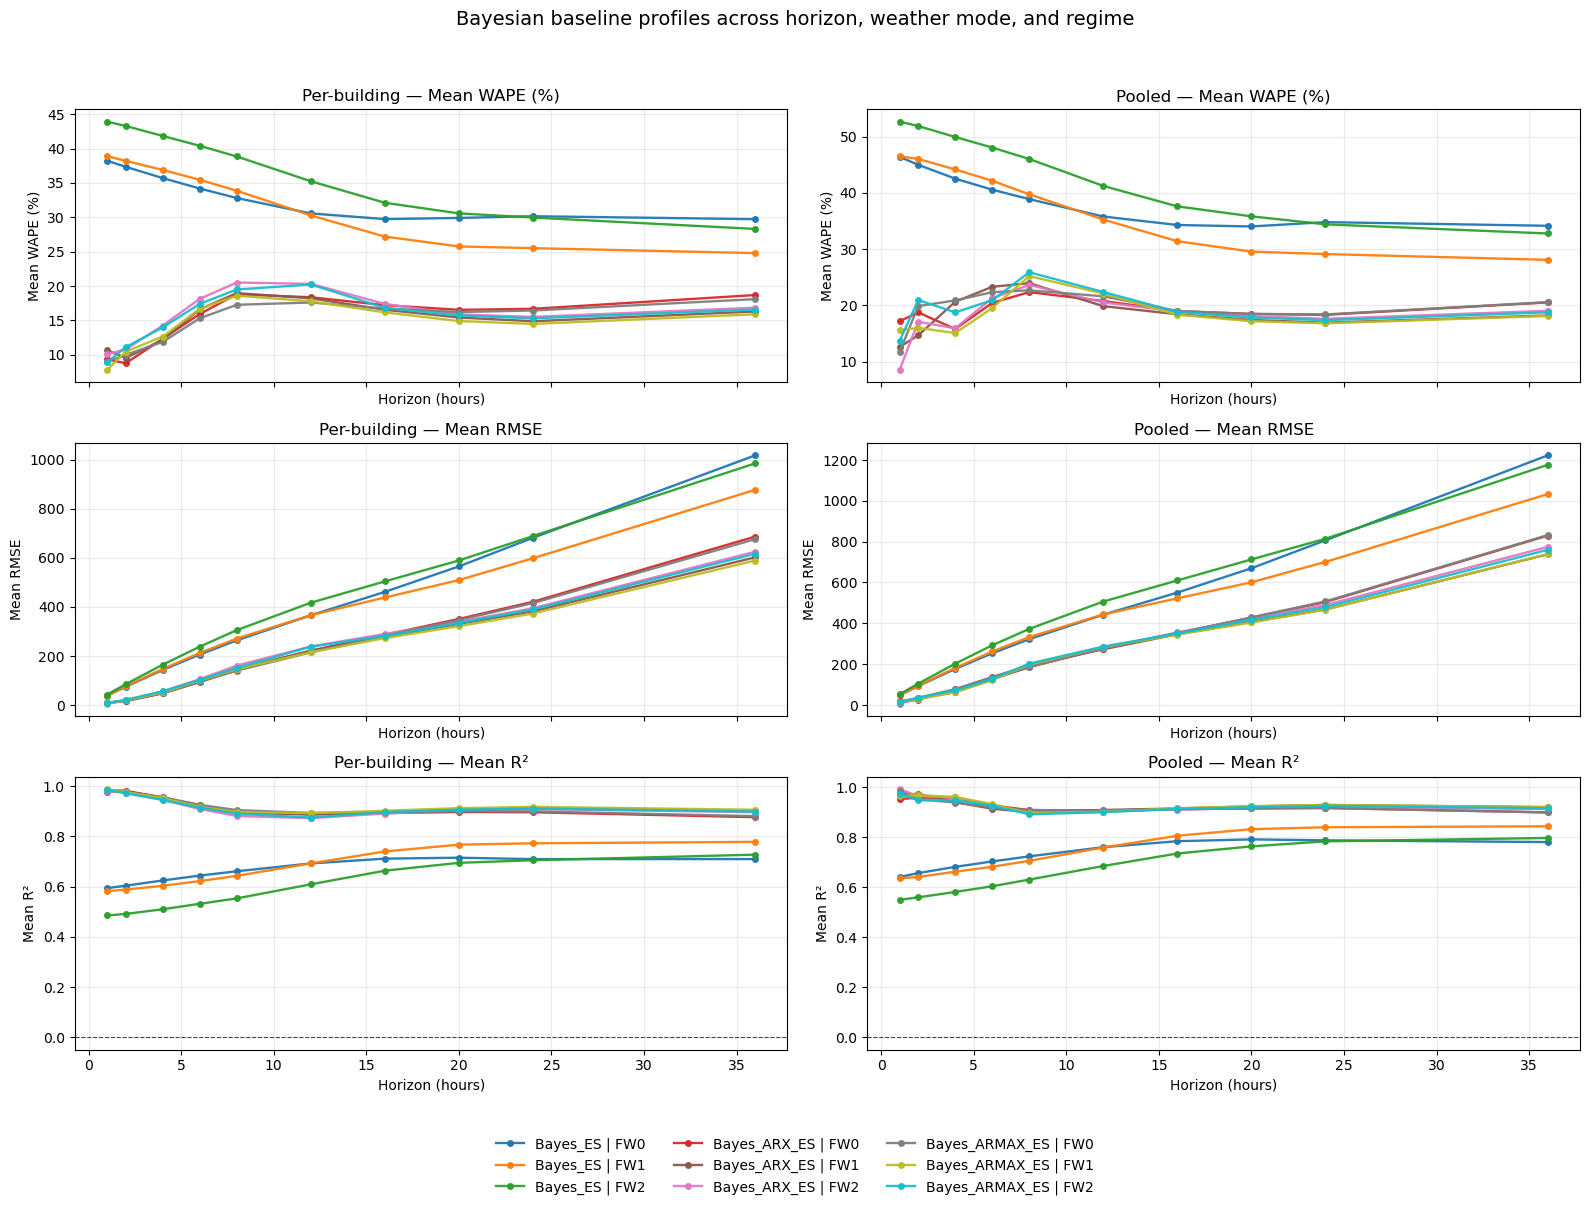

In [6]:
BASELINE_ORDER = ["Bayes_ES", "Bayes_ARX_ES", "Bayes_ARMAX_ES"]
WEATHER_ORDER = ["FW0", "FW1", "FW2"]
MODEL_ORDER = [f"{baseline} | {weather}" for baseline in BASELINE_ORDER for weather in WEATHER_ORDER]
REGIME_ORDER = ["Per-building", "Pooled"]
METRIC_SPECS = [
    ("mean_wape_pct", "Mean WAPE (%)", False),
    ("mean_rmse", "Mean RMSE", False),
    ("mean_r2", "Mean R²", True),
]

fig, axes = plt.subplots(len(METRIC_SPECS), len(REGIME_ORDER), figsize=(16, 12), sharex="col")
colors = plt.cm.tab10(np.linspace(0, 1, len(MODEL_ORDER)))
color_map = {label: colors[i] for i, label in enumerate(MODEL_ORDER)}

for col_idx, regime_label in enumerate(REGIME_ORDER):
    regime_df = BAYES_SUMMARY.loc[BAYES_SUMMARY["regime_label"] == regime_label].copy()
    for row_idx, (metric_col, title, higher_is_better) in enumerate(METRIC_SPECS):
        ax = axes[row_idx, col_idx]
        for label in MODEL_ORDER:
            model_df = regime_df.loc[regime_df["model_label"] == label].sort_values("horizon_h")
            if model_df.empty:
                continue
            ax.plot(
                model_df["horizon_h"],
                model_df[metric_col],
                marker="o",
                linewidth=1.7,
                markersize=4,
                color=color_map[label],
                label=label,
                alpha=0.95,
            )
        ax.set_xlabel("Horizon (hours)")
        ax.set_ylabel(title)
        ax.grid(alpha=0.25)
        if metric_col == "mean_r2":
            ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0.08, 1, 0.97])
fig.savefig(ANALYSIS_DIR / "bayes_metric_profiles.png", dpi=160, bbox_inches="tight")
plt.show()


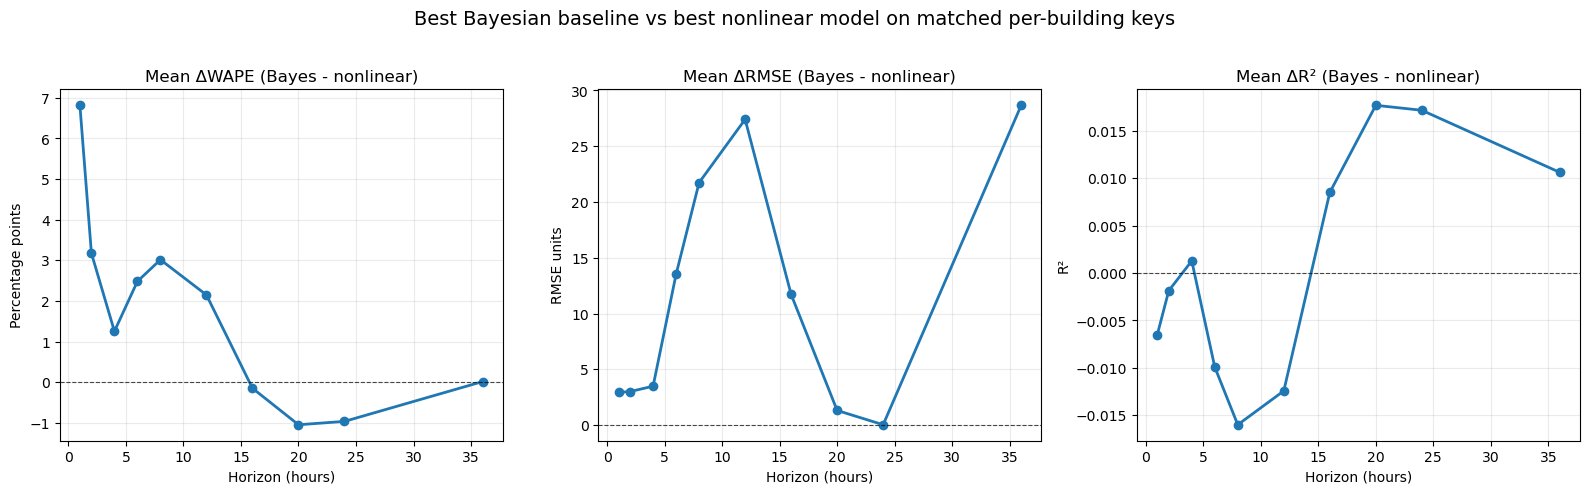

Interpretation: negative deltas for WAPE/RMSE mean the Bayesian baseline is better; positive delta for R² means the Bayesian baseline is better.
Note: these are matched on building / weather_mode / horizon only, and n_test_rows may differ from the nonlinear experiment.


,building,weather_mode,horizon_h,bayes_baseline,nl_label,wape_pct_bayes,wape_pct_nonlinear,delta_wape_pct_bayes_minus_nonlinear,rmse_bayes,rmse_nonlinear,delta_rmse_bayes_minus_nonlinear,r2_bayes,r2_nonlinear,delta_r2_bayes_minus_nonlinear,n_test_rows_gap
77,U02B,FW1,20,Bayes_ARMAX_ES,XGBOOST | M4,16.139995,22.149840,-6.009845,61.266048,81.907205,-20.641157,0.888769,0.798754,0.090014,587
88,U02B,FW2,24,Bayes_ARX_ES,XGBOOST | M4,15.727280,21.426850,-5.699569,71.374102,93.618387,-22.244285,0.893121,0.813656,0.079466,614
87,U02B,FW2,20,Bayes_ARX_ES,XGBOOST | M4,16.684622,21.932802,-5.248180,63.197808,80.131757,-16.933949,0.881532,0.807384,0.074148,614
107,U03,FW1,20,Bayes_ARMAX_ES,XGBOOST | M2,11.782925,16.811940,-5.029015,220.782294,336.977218,-116.194924,0.954463,0.893943,0.060520,587
78,U02B,FW1,24,Bayes_ARMAX_ES,LSTM | M2,15.024221,19.921374,-4.897153,69.339201,90.614878,-21.275677,0.899245,0.825421,0.073824,587
108,U03,FW1,24,Bayes_ARMAX_ES,XGBOOST | M2,11.589380,16.380205,-4.790825,260.760815,395.134544,-134.373729,0.955687,0.898118,0.057569,587
68,U02B,FW0,24,Bayes_ARMAX_ES,LSTM | M2,16.162069,20.468422,-4.306353,73.443196,90.456481,-17.013285,0.886965,0.826031,0.060935,587
109,U03,FW1,36,Bayes_ARMAX_ES,XGBOOST | M4,12.255037,16.553896,-4.298859,417.317561,618.591883,-201.274322,0.949129,0.887604,0.061525,587
67,U02B,FW0,20,Bayes_ARMAX_ES,LSTM | M4,16.879648,21.151028,-4.271381,63.489119,77.916024,-14.426906,0.880550,0.817889,0.062661,587
106,U03,FW1,16,Bayes_ARMAX_ES,XGBOOST | M2,12.057774,16.218065,-4.160292,176.764225,254.567511,-77.803286,0.954729,0.906285,0.048444,587


In [7]:
comparison_metrics_path = CONFIG.comparison_dir / "comparison_metrics.csv"

if comparison_metrics_path.exists():
    FAIR_WEATHER_MODE = "FW2"
    NONLINEAR = pd.read_csv(comparison_metrics_path)
    NONLINEAR = NONLINEAR.loc[
        (NONLINEAR["regime"].astype(str) == "per_building")
        & (NONLINEAR["weather_mode"].astype(str) == FAIR_WEATHER_MODE)
    ].copy()
    NONLINEAR["nl_label"] = NONLINEAR["model_family"].astype(str).str.upper() + " | " + NONLINEAR["mode"].astype(str)

    BAYES_PER_BUILDING = RUNS.loc[
        (RUNS["regime"].astype(str) == "per_building")
        & (RUNS["weather_mode"].astype(str) == FAIR_WEATHER_MODE)
    ].copy()
    BAYES_BEST = (
        BAYES_PER_BUILDING.sort_values(["fit_building", "weather_mode", "horizon_h", "wape_pct", "rmse", "r2"], ascending=[True, True, True, True, True, False])
        .drop_duplicates(["fit_building", "weather_mode", "horizon_h"], keep="first")
        .rename(
            columns={
                "fit_building": "building",
                "baseline": "bayes_baseline",
                "weather_mode": "weather_mode",
                "rmse": "rmse_bayes",
                "mae": "mae_bayes",
                "r2": "r2_bayes",
                "wape_pct": "wape_pct_bayes",
                "n_test_rows": "n_test_rows_bayes",
            }
        )
    )

    NL_BEST = (
        NONLINEAR.sort_values(["building", "weather_mode", "horizon_h", "wape_pct", "rmse", "r2"], ascending=[True, True, True, True, True, False])
        .drop_duplicates(["building", "weather_mode", "horizon_h"], keep="first")
        .rename(
            columns={
                "model_family": "nonlinear_family",
                "mode": "nonlinear_mode",
                "rmse": "rmse_nonlinear",
                "mae": "mae_nonlinear",
                "r2": "r2_nonlinear",
                "wape_pct": "wape_pct_nonlinear",
                "n_test_rows": "n_test_rows_nonlinear",
            }
        )
    )

    BAYES_VS_NONLINEAR = BAYES_BEST.merge(
        NL_BEST[
            [
                "building",
                "weather_mode",
                "horizon_h",
                "nonlinear_family",
                "nonlinear_mode",
                "nl_label",
                "rmse_nonlinear",
                "mae_nonlinear",
                "r2_nonlinear",
                "wape_pct_nonlinear",
                "n_test_rows_nonlinear",
            ]
        ],
        on=["building", "weather_mode", "horizon_h"],
        how="inner",
    )
    BAYES_VS_NONLINEAR["delta_wape_pct_bayes_minus_nonlinear"] = BAYES_VS_NONLINEAR["wape_pct_bayes"] - BAYES_VS_NONLINEAR["wape_pct_nonlinear"]
    BAYES_VS_NONLINEAR["delta_rmse_bayes_minus_nonlinear"] = BAYES_VS_NONLINEAR["rmse_bayes"] - BAYES_VS_NONLINEAR["rmse_nonlinear"]
    BAYES_VS_NONLINEAR["delta_r2_bayes_minus_nonlinear"] = BAYES_VS_NONLINEAR["r2_bayes"] - BAYES_VS_NONLINEAR["r2_nonlinear"]
    BAYES_VS_NONLINEAR["n_test_rows_gap"] = BAYES_VS_NONLINEAR["n_test_rows_bayes"] - BAYES_VS_NONLINEAR["n_test_rows_nonlinear"]
    BAYES_VS_NONLINEAR.to_csv(ANALYSIS_DIR / "bayes_vs_nonlinear_best_matchups.csv", index=False)

    HORIZON_DELTA = (
        BAYES_VS_NONLINEAR.groupby("horizon_h", dropna=False)
        .agg(
            mean_delta_wape_pct=("delta_wape_pct_bayes_minus_nonlinear", "mean"),
            mean_delta_rmse=("delta_rmse_bayes_minus_nonlinear", "mean"),
            mean_delta_r2=("delta_r2_bayes_minus_nonlinear", "mean"),
            mean_n_test_rows_gap=("n_test_rows_gap", "mean"),
            cases=("building", "count"),
        )
        .reset_index()
    )
    HORIZON_DELTA.to_csv(ANALYSIS_DIR / "bayes_vs_nonlinear_horizon_summary.csv", index=False)

    fig, axes = plt.subplots(3, 1, figsize=(8.5, 11), sharex=True)
    PLOT_SPECS = [
        ("mean_delta_wape_pct", "Mean ΔWAPE (Bayes - nonlinear)", "Percentage points"),
        ("mean_delta_rmse", "Mean ΔRMSE (Bayes - nonlinear)", "RMSE units"),
        ("mean_delta_r2", "Mean ΔR² (Bayes - nonlinear)", "R²"),
    ]
    for ax, (col, title, ylabel) in zip(axes, PLOT_SPECS):
        ax.plot(HORIZON_DELTA["horizon_h"], HORIZON_DELTA[col], marker="o", linewidth=2.0, color="#1f77b4")
        ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)
        ax.set_xlabel("Horizon (hours)")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
    plt.tight_layout()
    fig.savefig(ANALYSIS_DIR / "bayes_vs_nonlinear_horizon_deltas.png", dpi=160, bbox_inches="tight")
    plt.show()

    print(f"Fair comparison weather mode: {FAIR_WEATHER_MODE}")
    print("Interpretation: negative deltas for WAPE/RMSE mean the Bayesian baseline is better; positive delta for R² means the Bayesian baseline is better.")
    print("FW1 remains available in the notebook as an oracle upper bound, but it is excluded from this benchmark comparison.")
    print("Note: these are matched on building / weather_mode / horizon only, and n_test_rows may differ from the nonlinear experiment.")
    display(
        BAYES_VS_NONLINEAR[
            [
                "building",
                "weather_mode",
                "horizon_h",
                "bayes_baseline",
                "nl_label",
                "wape_pct_bayes",
                "wape_pct_nonlinear",
                "delta_wape_pct_bayes_minus_nonlinear",
                "rmse_bayes",
                "rmse_nonlinear",
                "delta_rmse_bayes_minus_nonlinear",
                "r2_bayes",
                "r2_nonlinear",
                "delta_r2_bayes_minus_nonlinear",
                "n_test_rows_gap",
            ]
        ].sort_values(["delta_wape_pct_bayes_minus_nonlinear", "delta_rmse_bayes_minus_nonlinear"], ascending=[True, True]).head(20)
    )
else:
    print(f"Nonlinear comparison file not found: {comparison_metrics_path}")


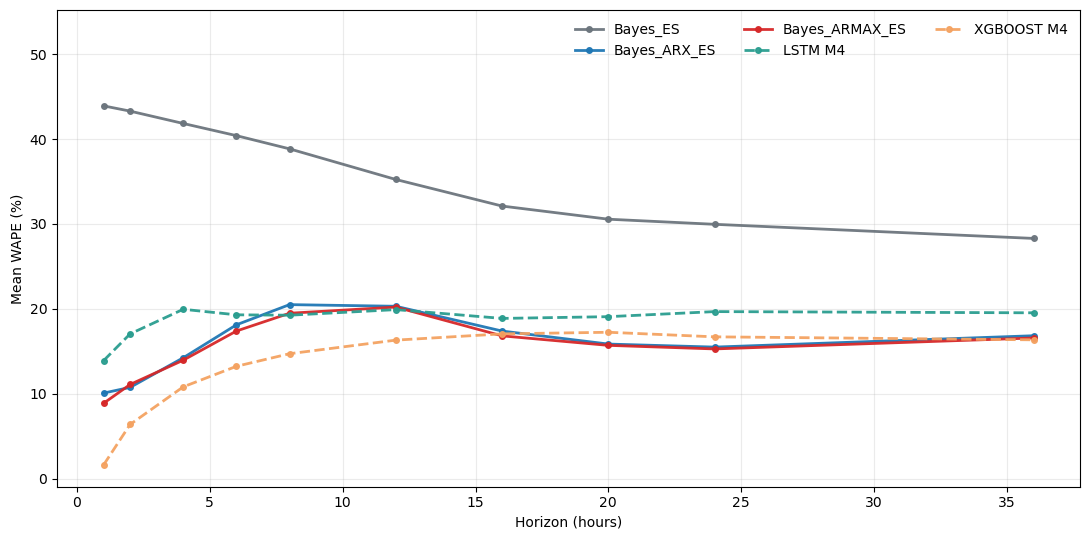

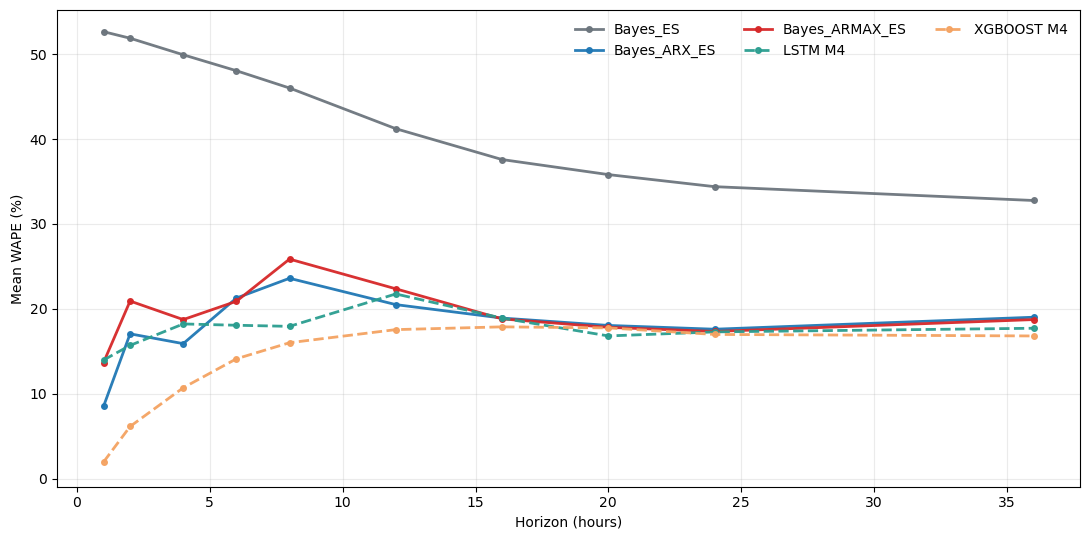

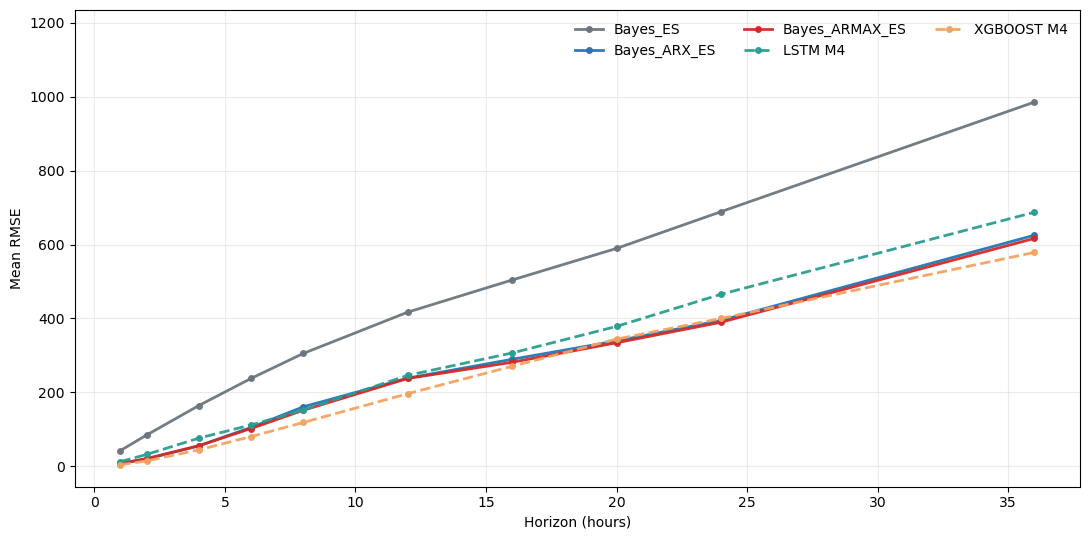

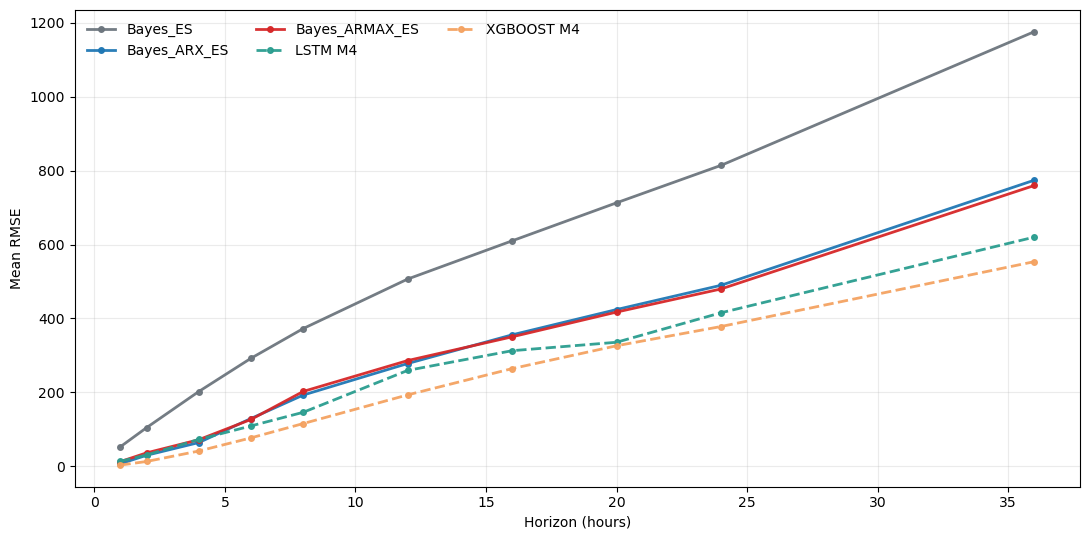

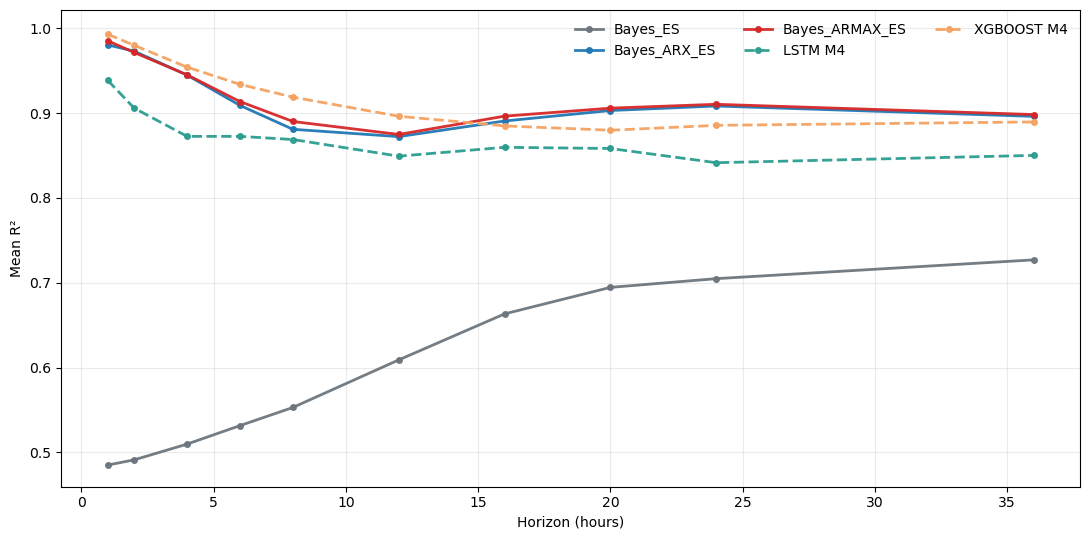

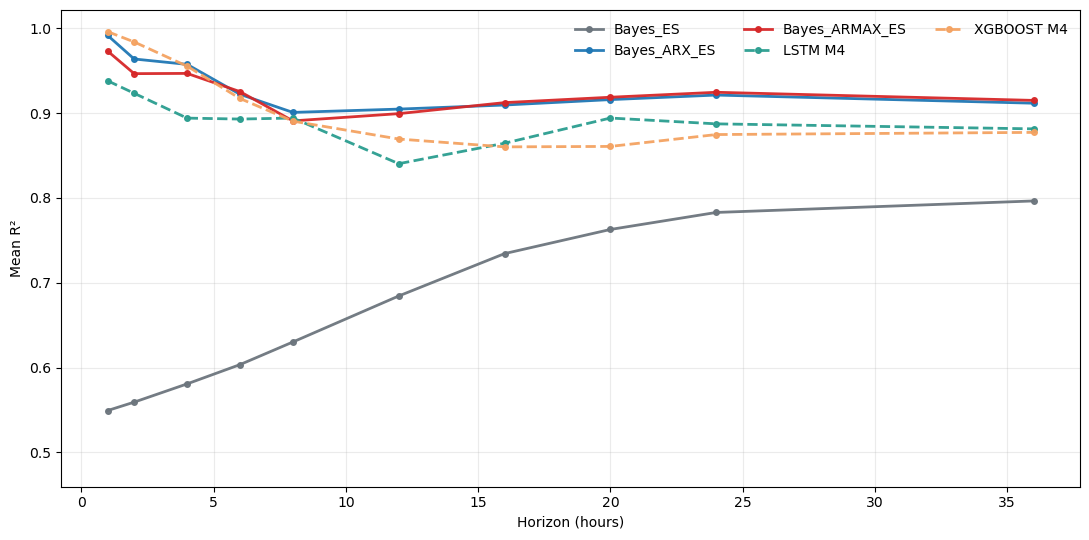

In [10]:
BAYES_BASELINE_AVG = (
    RUNS.groupby(["regime_label", "weather_mode", "baseline", "horizon_h"], dropna=False)
    .agg(
        mean_wape_pct=("wape_pct", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_r2=("r2", "mean"),
        mean_divergences=("divergences", "mean"),
        buildings=("fit_building", "nunique"),
    )
    .reset_index()
)
BAYES_BASELINE_AVG.to_csv(ANALYSIS_DIR / "bayes_baseline_family_average.csv", index=False)

comparison_metrics_path = CONFIG.comparison_dir / "comparison_metrics.csv"
OVERLAY_WEATHER_MODE = "FW2"
OVERLAY_MODE = "M4"

overlay_rows = []
for regime_label, regime_name in [("Per-building", "per_building"), ("Pooled", "pooled_same_buildings")]:
    bayes_slice = BAYES_BASELINE_AVG.loc[
        (BAYES_BASELINE_AVG["regime_label"] == regime_label)
        & (BAYES_BASELINE_AVG["weather_mode"] == OVERLAY_WEATHER_MODE)
    ].copy()
    if not bayes_slice.empty:
        bayes_slice["series_label"] = bayes_slice["baseline"].astype(str)
        overlay_rows.append(
            bayes_slice[["regime_label", "horizon_h", "series_label", "mean_wape_pct", "mean_rmse", "mean_r2"]]
        )

if comparison_metrics_path.exists():
    nonlinear = pd.read_csv(comparison_metrics_path)
    nonlinear = nonlinear.loc[
        (nonlinear["weather_mode"].astype(str) == OVERLAY_WEATHER_MODE)
        & (nonlinear["mode"].astype(str) == OVERLAY_MODE)
        & (nonlinear["model_family"].astype(str).isin(["lstm", "xgboost"]))
    ].copy()
    nonlinear["regime_label"] = nonlinear["regime"].map(
        {
            "per_building": "Per-building",
            "pooled_same_buildings": "Pooled",
        }
    ).fillna(nonlinear["regime"])
    nonlinear_avg = (
        nonlinear.groupby(["regime_label", "model_family", "horizon_h"], dropna=False)
        .agg(
            mean_wape_pct=("wape_pct", "mean"),
            mean_rmse=("rmse", "mean"),
            mean_r2=("r2", "mean"),
        )
        .reset_index()
    )
    nonlinear_avg["series_label"] = nonlinear_avg["model_family"].astype(str).str.upper() + f" {OVERLAY_MODE}"
    overlay_rows.append(
        nonlinear_avg[["regime_label", "horizon_h", "series_label", "mean_wape_pct", "mean_rmse", "mean_r2"]]
    )
else:
    print(f"Comparison file missing for overlay: {comparison_metrics_path}")

BAYES_NONLINEAR_OVERLAY = pd.concat(overlay_rows, ignore_index=True) if overlay_rows else pd.DataFrame()
BAYES_NONLINEAR_OVERLAY.to_csv(ANALYSIS_DIR / "bayes_nonlinear_fw2_m4_overlay.csv", index=False)

series_order = ["Bayes_ES", "Bayes_ARX_ES", "Bayes_ARMAX_ES", "LSTM M4", "XGBOOST M4"]
series_colors = {
    "Bayes_ES": "#6c757d",
    "Bayes_ARX_ES": "#1f77b4",
    "Bayes_ARMAX_ES": "#d62728",
    "LSTM M4": "#2a9d8f",
    "XGBOOST M4": "#f4a261",
}
series_styles = {
    "Bayes_ES": "-",
    "Bayes_ARX_ES": "-",
    "Bayes_ARMAX_ES": "-",
    "LSTM M4": "--",
    "XGBOOST M4": "--",
}
metric_specs = [
    ("mean_wape_pct", "Mean WAPE (%)", "bayes_vs_nonlinear_overlay_wape.png"),
    ("mean_rmse", "Mean RMSE", "bayes_vs_nonlinear_overlay_rmse.png"),
    ("mean_r2", "Mean R²", "bayes_vs_nonlinear_overlay_r2.png"),
]
regime_order = ["Per-building", "Pooled"]

for metric_col, ylabel, filename in metric_specs:
    y_limits = []
    for regime_label in regime_order:
        regime_df = BAYES_NONLINEAR_OVERLAY.loc[BAYES_NONLINEAR_OVERLAY["regime_label"] == regime_label].copy()
        vals = pd.to_numeric(regime_df[metric_col], errors="coerce").dropna()
        if not vals.empty:
            y_limits.extend([float(vals.min()), float(vals.max())])
    y_min = min(y_limits) if y_limits else None
    y_max = max(y_limits) if y_limits else None

    for regime_label in regime_order:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5.5))
        regime_df = BAYES_NONLINEAR_OVERLAY.loc[BAYES_NONLINEAR_OVERLAY["regime_label"] == regime_label].copy()
        for label in series_order:
            series_df = regime_df.loc[regime_df["series_label"] == label].sort_values("horizon_h")
            if series_df.empty:
                continue
            ax.plot(
                series_df["horizon_h"],
                series_df[metric_col],
                marker="o",
                markersize=4,
                linewidth=2.0,
                linestyle=series_styles[label],
                color=series_colors[label],
                alpha=0.95,
                label=label,
            )
        if metric_col == "mean_r2":
            ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
        ax.set_xlabel("Horizon (hours)")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
        if y_min is not None and y_max is not None and y_max > y_min:
            pad = 0.05 * (y_max - y_min)
            ax.set_ylim(y_min - pad, y_max + pad)
        ax.legend(loc="best", frameon=False, ncol=3)
        plt.tight_layout()
        regime_slug = regime_label.lower().replace("-", "_").replace(" ", "_")
        out_name = filename.replace(".png", f"_{regime_slug}.png")
        fig.savefig(ANALYSIS_DIR / out_name, dpi=160, bbox_inches="tight")
        plt.show()


## Final FW2 WAPE Comparison

Two clean FW2 WAPE figures: all Bayesian baseline families, then the globally best baseline family overlaid with nonlinear M4 models.


Selected best FW2 baseline family for overlay: Bayes_ARX_ES


,baseline,avg_wape_pct
0,Bayes_ARX_ES,17.010003
1,Bayes_ARMAX_ES,17.537364
2,Bayes_ES,39.730794


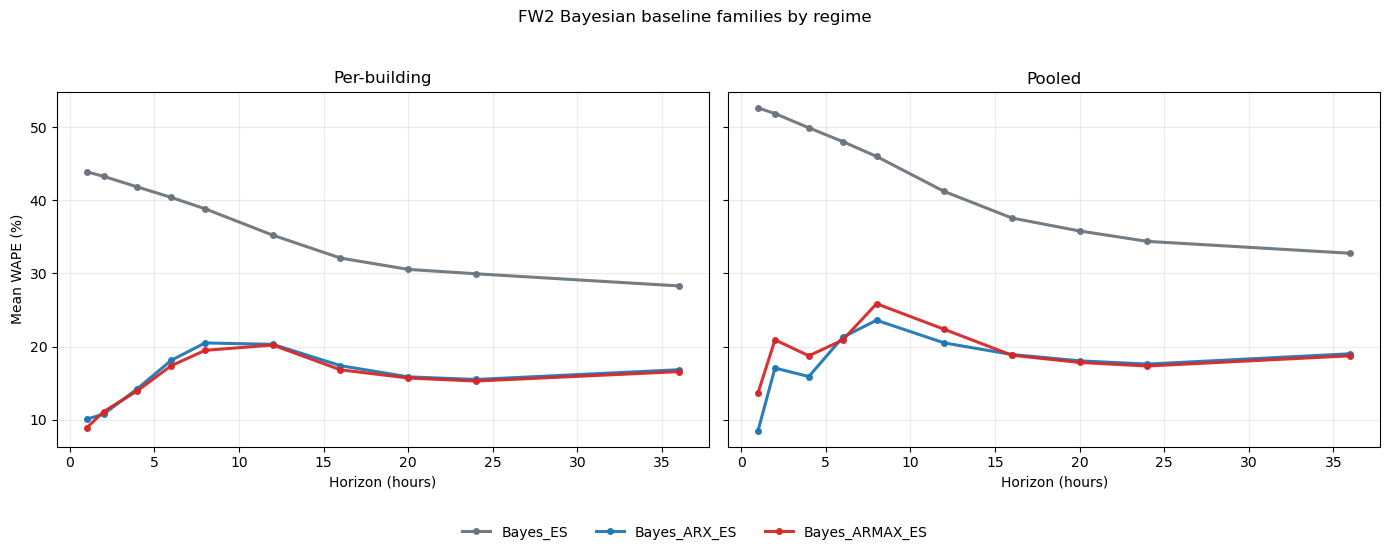

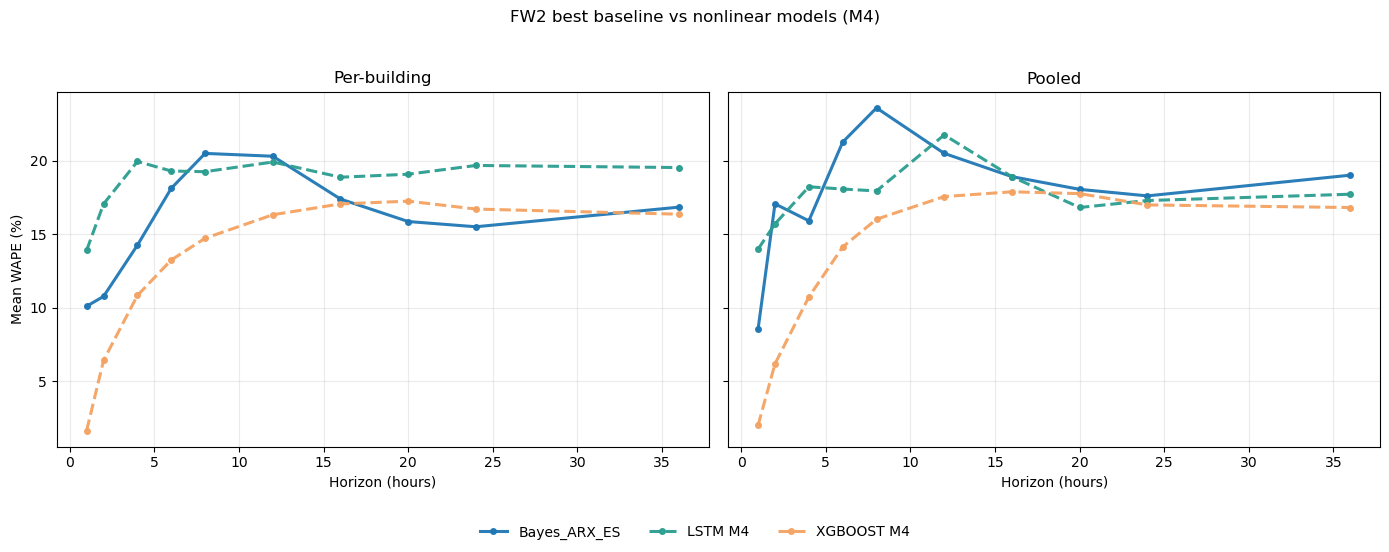

Saved figures to: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/bayesian_es_baselines_20042026/analysis


In [11]:
FW2_WEATHER_MODE = "FW2"
FW2_NONLINEAR_MODE = "M4"
FW2_REGIME_ORDER = ["Per-building", "Pooled"]
FW2_BASELINE_ORDER = ["Bayes_ES", "Bayes_ARX_ES", "Bayes_ARMAX_ES"]
FW2_COLOR_MAP = {
    "Bayes_ES": "#6c757d",
    "Bayes_ARX_ES": "#1f77b4",
    "Bayes_ARMAX_ES": "#d62728",
    "LSTM M4": "#2a9d8f",
    "XGBOOST M4": "#f4a261",
}
FW2_STYLE_MAP = {
    "Bayes_ES": "-",
    "Bayes_ARX_ES": "-",
    "Bayes_ARMAX_ES": "-",
    "LSTM M4": "--",
    "XGBOOST M4": "--",
}

FW2_BASELINE_WAPE = (
    RUNS.loc[RUNS["weather_mode"].astype(str) == FW2_WEATHER_MODE]
    .groupby(["regime_label", "baseline", "horizon_h"], dropna=False)
    .agg(mean_wape_pct=("wape_pct", "mean"))
    .reset_index()
)
FW2_BASELINE_WAPE.to_csv(ANALYSIS_DIR / "fw2_baseline_wape_summary.csv", index=False)

FW2_BASELINE_GLOBAL_RANKING = (
    FW2_BASELINE_WAPE.groupby("baseline", dropna=False)
    .agg(avg_wape_pct=("mean_wape_pct", "mean"))
    .reset_index()
    .sort_values(["avg_wape_pct", "baseline"], ascending=[True, True])
    .reset_index(drop=True)
)
BEST_FW2_BASELINE_FAMILY = str(FW2_BASELINE_GLOBAL_RANKING.iloc[0]["baseline"])

comparison_metrics_path = CONFIG.comparison_dir / "comparison_metrics.csv"
if not comparison_metrics_path.exists():
    raise FileNotFoundError(f"Comparison metrics file not found: {comparison_metrics_path}")

nonlinear = pd.read_csv(comparison_metrics_path)
nonlinear = nonlinear.loc[
    (nonlinear["weather_mode"].astype(str) == FW2_WEATHER_MODE)
    & (nonlinear["mode"].astype(str) == FW2_NONLINEAR_MODE)
    & (nonlinear["model_family"].astype(str).isin(["lstm", "xgboost"]))
].copy()
nonlinear["regime_label"] = nonlinear["regime"].map(
    {
        "per_building": "Per-building",
        "pooled_same_buildings": "Pooled",
    }
).fillna(nonlinear["regime"])
FW2_NONLINEAR_WAPE = (
    nonlinear.groupby(["regime_label", "model_family", "horizon_h"], dropna=False)
    .agg(mean_wape_pct=("wape_pct", "mean"))
    .reset_index()
)
FW2_NONLINEAR_WAPE["series_label"] = FW2_NONLINEAR_WAPE["model_family"].astype(str).str.upper() + f" {FW2_NONLINEAR_MODE}"

FW2_BASELINE_PLOT = FW2_BASELINE_WAPE.rename(columns={"baseline": "series_label"})[
    ["regime_label", "horizon_h", "series_label", "mean_wape_pct"]
].copy()
FW2_BEST_BASELINE_OVERLAY = pd.concat(
    [
        FW2_BASELINE_PLOT.loc[
            FW2_BASELINE_PLOT["series_label"] == BEST_FW2_BASELINE_FAMILY,
            ["regime_label", "horizon_h", "series_label", "mean_wape_pct"],
        ],
        FW2_NONLINEAR_WAPE[["regime_label", "horizon_h", "series_label", "mean_wape_pct"]],
    ],
    ignore_index=True,
)
FW2_BEST_BASELINE_OVERLAY.to_csv(
    ANALYSIS_DIR / "fw2_best_baseline_vs_nonlinear_m4_wape.csv",
    index=False,
)


def _plot_fw2_wape_panels(plot_df: pd.DataFrame, series_order: list[str], title: str, filename: str) -> None:
    fig, axes = plt.subplots(1, len(FW2_REGIME_ORDER), figsize=(14, 5.5), sharey=True)
    y_values = pd.to_numeric(plot_df["mean_wape_pct"], errors="coerce").dropna()
    if not y_values.empty:
        y_min = float(y_values.min())
        y_max = float(y_values.max())
        y_span = max(y_max - y_min, 1.0)
        y_pad = 0.05 * y_span
    else:
        y_min = y_max = y_pad = None

    for ax, regime_label in zip(axes, FW2_REGIME_ORDER):
        regime_df = plot_df.loc[plot_df["regime_label"] == regime_label].copy()
        for label in series_order:
            series_df = regime_df.loc[regime_df["series_label"] == label].sort_values("horizon_h")
            if series_df.empty:
                continue
            ax.plot(
                series_df["horizon_h"],
                series_df["mean_wape_pct"],
                marker="o",
                markersize=4,
                linewidth=2.2,
                linestyle=FW2_STYLE_MAP[label],
                color=FW2_COLOR_MAP[label],
                alpha=0.95,
                label=label,
            )
        ax.set_title(regime_label)
        ax.set_xlabel("Horizon (hours)")
        ax.grid(alpha=0.25)
        if y_min is not None and y_max is not None:
            ax.set_ylim(y_min - y_pad, y_max + y_pad)

    axes[0].set_ylabel("Mean WAPE (%)")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=len(series_order), frameon=False)
    fig.suptitle(title, y=0.98)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    fig.savefig(ANALYSIS_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


print(f"Selected best FW2 baseline family for overlay: {BEST_FW2_BASELINE_FAMILY}")
display(FW2_BASELINE_GLOBAL_RANKING)

_plot_fw2_wape_panels(
    FW2_BASELINE_PLOT,
    series_order=FW2_BASELINE_ORDER,
    title="FW2 Bayesian baseline families by regime",
    filename="fw2_baseline_families_wape.png",
)
_plot_fw2_wape_panels(
    FW2_BEST_BASELINE_OVERLAY,
    series_order=[BEST_FW2_BASELINE_FAMILY, "LSTM M4", "XGBOOST M4"],
    title=f"FW2 best baseline vs nonlinear models ({FW2_NONLINEAR_MODE})",
    filename="fw2_best_baseline_vs_nonlinear_m4_wape.png",
)

print(f"Saved figures to: {ANALYSIS_DIR}")
